# Kaggle Dataset

In [ ]:
!pip install kaggle

!mkdir -p ~/.kaggle

from google.colab import files
files.upload()

!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download the dataset
!kaggle datasets download -d drscarlat/melanoma

# Unzip the downloaded file
!unzip -q melanoma.zip -d melanoma_dataset

# List the contents to verify
!ls melanoma_dataset

In [ ]:
!pip install ultralytics -q

In [ ]:
from ultralytics import YOLO

In [ ]:
model = YOLO('yolov8s-cls.pt')

In [ ]:
model.train(
    data='/content/melanoma_dataset',
    epochs=50,
    imgsz=240,
    batch=16,
    device=0,
)

In [ ]:
model.val(data='/content/melanoma_dataset')

Ultralytics 8.4.128 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
train: /content/melanoma_dataset/train... found 10682 images in 2 classes ✅ 
val: /content/melanoma_dataset/valid... found 3562 images in 2 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 272.1±107.1 MB/s, size: 6.4 KB)
val: Scanning /content/melanoma_dataset/valid... 3562 images, 0 corrupt: 100% ━━━━━━━━━━━━ 3562/3562 996.0Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 223/223 11.4it/s 19.6s
                   all       0.95          1
Speed: 0.1ms preprocess, 1.1ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val-2


ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a7a050163c0>
curves: []
curves_results: []
fitness: 0.9751543998718262
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.9503087997436523, 'metrics/accuracy_top5': 1.0, 'fitness': 0.9751543998718262}
save_dir: PosixPath('/content/runs/classify/val-2')
speed: {'preprocess': 0.08474241915146966, 'inference': 1.0653539455413594, 'loss': 0.0007764382384453258, 'postprocess': 0.0017987571582171345}
top1: 0.9503087997436523
top5: 1.0

# test the model

In [ ]:
import glob
import random
from PIL import Image
import matplotlib.pyplot as plt

best_model_path = '/content/runs/classify/train/weights/best.pt'

# Load the best trained model
model = YOLO(best_model_path)

In [ ]:
# Define paths to test image directories
melanoma_test_dir = '/content/test/Melanoma'
not_melanoma_test_dir = '/content/test/NotMelanoma'

# Get lists of image files
melanoma_images = glob.glob(f"{melanoma_test_dir}/*.jpg") + glob.glob(f"{melanoma_test_dir}/*.png")
not_melanoma_images = glob.glob(f"{not_melanoma_test_dir}/*.jpg") + glob.glob(f"{not_melanoma_test_dir}/*.png")

# Select 6 random images from each category
selected_melanoma_images = random.sample(melanoma_images, min(6, len(melanoma_images)))
selected_not_melanoma_images = random.sample(not_melanoma_images, min(6, len(not_melanoma_images)))

# Combine selected images for prediction
all_selected_images = selected_melanoma_images + selected_not_melanoma_images

print(f"Selected Melanoma images: {len(selected_melanoma_images)}")
print(f"Selected NotMelanoma images: {len(selected_not_melanoma_images)}")

Selected Melanoma images: 6
Selected NotMelanoma images: 6



0: 256x256 Melanoma 0.76, NotMelanoma 0.24, 1.8ms
1: 256x256 NotMelanoma 0.97, Melanoma 0.03, 1.8ms
2: 256x256 Melanoma 0.92, NotMelanoma 0.08, 1.8ms
3: 256x256 Melanoma 0.76, NotMelanoma 0.24, 1.8ms
4: 256x256 NotMelanoma 0.74, Melanoma 0.26, 1.8ms
5: 256x256 Melanoma 0.96, NotMelanoma 0.04, 1.8ms
6: 256x256 NotMelanoma 1.00, Melanoma 0.00, 1.8ms
7: 256x256 NotMelanoma 0.96, Melanoma 0.04, 1.8ms
8: 256x256 NotMelanoma 0.96, Melanoma 0.04, 1.8ms
9: 256x256 NotMelanoma 0.82, Melanoma 0.18, 1.8ms
10: 256x256 NotMelanoma 1.00, Melanoma 0.00, 1.8ms
11: 256x256 NotMelanoma 1.00, Melanoma 0.00, 1.8ms
Speed: 4.5ms preprocess, 1.8ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)


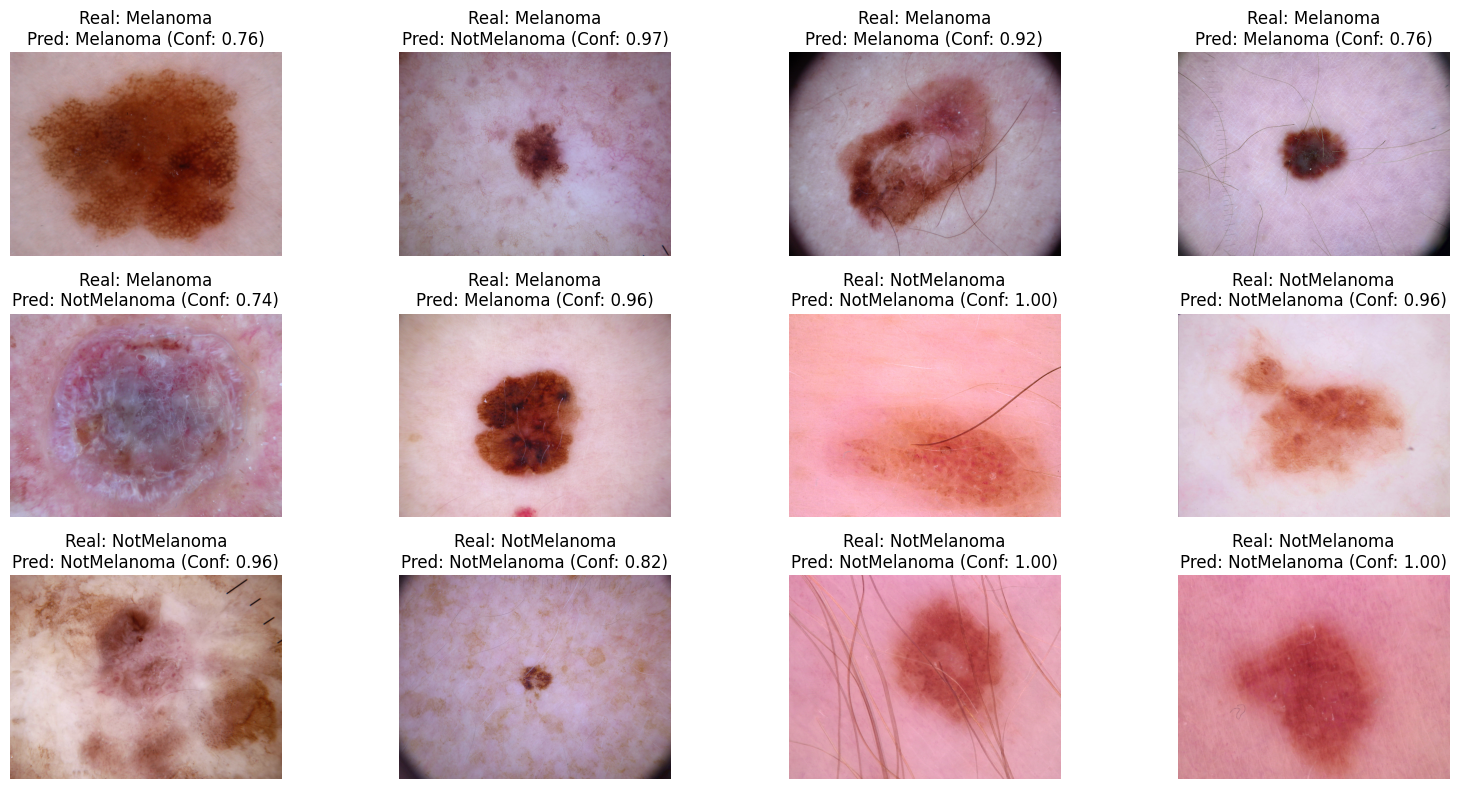

In [ ]:
import os

# Run predictions on the selected images
results = model(all_selected_images)

# Create a single figure with 3 rows and 4 columns for the images
fig, axes = plt.subplots(3, 4, figsize=(16, 8))
axes = axes.flatten() # Flatten the 2x4 array of axes for easy iteration

# Display the results for each image
for i, result in enumerate(results):
    image_path = all_selected_images[i]

    # Get predicted class and confidence
    probs = result.probs # Probs object contains probabilities for each class
    predicted_class_idx = probs.top1
    confidence = probs.top1conf.item()
    predicted_class_name = model.names[predicted_class_idx]

    # Get the real label from the image path
    real_label = os.path.basename(os.path.dirname(image_path))

    # Display the image in the current subplot
    img = Image.open(image_path)
    axes[i].imshow(img)
    axes[i].set_title(f"Real: {real_label}\nPred: {predicted_class_name} (Conf: {confidence:.2f})")
    axes[i].axis('off') # Hide axes ticks and labels

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show() # Display the entire figure

# ISIC Dataset


In [ ]:
!wget "https://isic-archive.s3.amazonaws.com/challenges/2019/ISIC_2019_Training_Input.zip"

In [ ]:
!wget "https://isic-archive.s3.amazonaws.com/challenges/2019/ISIC_2019_Training_GroundTruth.csv"

In [ ]:
# Unzip the downloaded file
!unzip -q ISIC_2019_Training_Input.zip -d dataset

In [ ]:
#ISIC Dataset preparation for google colab
import pandas as pd
import os, shutil
from sklearn.model_selection import train_test_split


csv_path = "ISIC_2019_Training_GroundTruth.csv"
images_path = "dataset/ISIC_2019_Training_Input"
output_path = "dataset_melanoma"


df = pd.read_csv(csv_path)

df["label"] = df.iloc[:, 1:].idxmax(axis=1)


train_df, val_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=42)


extensions = [".jpg", ".jpeg", ".png"]


def prepare_split(split_df, split_name):
    for _, row in split_df.iterrows():
        img_base = row["image"]
        src = None


        for ext in extensions:
            candidate = os.path.join(images_path, img_base + ext)
            if os.path.exists(candidate):
                src = candidate
                break

        if src:
            dst = os.path.join(output_path, split_name, row["label"], os.path.basename(src))
            os.makedirs(os.path.dirname(dst), exist_ok=True)
            shutil.copy(src, dst)
        else:
            print(f" فایل پیدا نشد: {img_base}")

prepare_split(train_df, "train")
prepare_split(val_df, "val")

print("دیتاست آماده شد  ")


دیتاست آماده شد  


In [ ]:
#Datasets files number
import os

dataset_dir = "/content/dataset_melanoma"

if not os.path.exists(dataset_dir):
    print(f" مسیر {dataset_dir} وجود نداره")
else:
    for root, dirs, files in os.walk(dataset_dir):
        print(f"📂 {root} : {len(files)} فایل")


📂 /content/dataset_melanoma : 0 فایل
📂 /content/dataset_melanoma/train : 0 فایل
📂 /content/dataset_melanoma/train/NV : 10300 فایل
📂 /content/dataset_melanoma/train/AK : 694 فایل
📂 /content/dataset_melanoma/train/SCC : 502 فایل
📂 /content/dataset_melanoma/train/DF : 191 فایل
📂 /content/dataset_melanoma/train/VASC : 202 فایل
📂 /content/dataset_melanoma/train/MEL : 3618 فایل
📂 /content/dataset_melanoma/train/BKL : 2099 فایل
📂 /content/dataset_melanoma/train/BCC : 2658 فایل
📂 /content/dataset_melanoma/val : 0 فایل
📂 /content/dataset_melanoma/val/NV : 2575 فایل
📂 /content/dataset_melanoma/val/AK : 173 فایل
📂 /content/dataset_melanoma/val/SCC : 126 فایل
📂 /content/dataset_melanoma/val/DF : 48 فایل
📂 /content/dataset_melanoma/val/VASC : 51 فایل
📂 /content/dataset_melanoma/val/MEL : 904 فایل
📂 /content/dataset_melanoma/val/BKL : 525 فایل
📂 /content/dataset_melanoma/val/BCC : 665 فایل


In [ ]:
model.train(
    data='/content/dataset_melanoma',
    epochs=50,
    imgsz=960,
    batch=16,
    device=0,
)

In [ ]:
model.val()